<a href="https://colab.research.google.com/github/alexandre-bismuth/Geometric-Deep-Learning/blob/main/practical_2_gnns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Practical 2**
## A Graph Neural Network Model for Node Classification
### (and how to build it from scratch)

### Overview
In this practical, you will implement the base graph neural network model from scratch (without using PyTorch Geometric), and prepare it for node classification. You will train your model for node classification on Cora dataset, which is an academic citation network. The task is to predict the category of each paper (which corresponds to a node in the citation network) among the seven available.

For each part and task, answer the given questions and complete the code where missing (this is indicated by the `pass` keyword).

## Part 0: Installing dependencies
Despite the fact we will not use PyTorch Geometric to build the GNN, we will use it to handle the Cora dataset, as it is included in the base distribution.
Follow the given instructions to set up your Colab notebook correctly.

First of all, we advice you to enable GPU acceleration for your notebook. This can be done by navigating to `Runtime > Change runtime type > Hardware accelerator (GPU) > Save`. You may getting an error explaining that no GPUs are currently available. This is fine, you don't really need them for this practical, however they'll make your computations significantly faster.

Some other tips & tricks:
- press `Shift + Enter` to run a cell and move to the next one (`Ctrl + Enter` to only run it)
- when you execute a cell, the variables you create are saved into a global namespace. As a consequence, changes in the code will not take effect until you re-run that specific cell.
- remember to save your notebook every once in a while!

In [2]:
%%capture
%pip install torch-geometric==2.7.0

### Part 0.1: Downloading and visualizing the Data
In this part, you will build a GNN using PyTorch, aiming to emulate the PyTorch Geometric modules. You will construct your neural network using PyTorch nn modules, and build training and testing helper functions to train and evaluate your model.

We will be working with the Cora citation dataset made popular by the work on graph convolutional networks of [Kipf and Welling (2017)](https://arxiv.org/abs/1609.02907). The nodes in the Cora dataset represents papers, and edges represent citation links between them. For simplicity, we treat the network as undirected (there is a link between paper A and B if either A cites B or vice versa). In addition, each node comes with a set of attributes (bag-of-words features extracted from the corresponding paper) and a label (the field where the paper was published).


First of all, load the Cora dataset and compute some statistics associated with the network:

In [3]:
# Let's first import all the things we are gonna need for this task

import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
import networkx as nx
from copy import deepcopy
# torch_geometric only used to load the Cora dataset
from torch_geometric.datasets import Planetoid
from torch_geometric.loader import DataLoader
import torch_geometric.utils as U
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt


device = torch.device("cuda") if torch.cuda.is_available() else torch.device("gpu")

dataset = Planetoid("/tmp/Cora", name="Cora")


class ID(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x

Processing...
Done!


**Note: How PyTorch represents the data**

The `dataset.data` variable contains information about the Cora citation graph, the node features and the node labels. Nodes are indexed $0, \ldots, n-1$. Edges are given by the $2 \times |E|$ tensor `dataset.data.edge_index` where each column contains two numbers $u$ and $v$ representing a directed edge `u → v`. In PyTorch Geometric all graphs are directed. We can represent an undirected graph by representing each undirected edge `u ~ v` with two directed edges `u → v` and  `v → u`. Because we are treating Cora as an undirected graph, we divide `dataset.data.num_edges` by 2 to count the number of (undirected) edges. The node features are stored in the $n \times d$ matrix `dataset.data.x` with the $i$th row being the feature vector for node $i$. Finally node labels are given by the vector `dataset.data.y` where the $i$th entry is the label for node $i$.

In [4]:

num_nodes = dataset.data.num_nodes
num_edges = dataset.data.num_edges // 2
num_features = dataset.num_node_features
num_classes = dataset.num_classes


print('Number of nodes:', num_nodes)
print('Number of edges:', num_edges)
print('Feature dimension:', num_features)
print('Num classes:', num_classes)

Number of nodes: 2708
Number of edges: 5278
Feature dimension: 1433
Num classes: 7


/tmp/ipython-input-1596956189.py:1: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  num_nodes = dataset.data.num_nodes
/tmp/ipython-input-1596956189.py:2: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  num_edges = dataset.data.num_edges // 2


A quick look at node label statistics. Recall that the nodes represent a research paper. The corresponding label is the research subfield.  

/tmp/ipython-input-275637489.py:3: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  labels = dataset.data.y


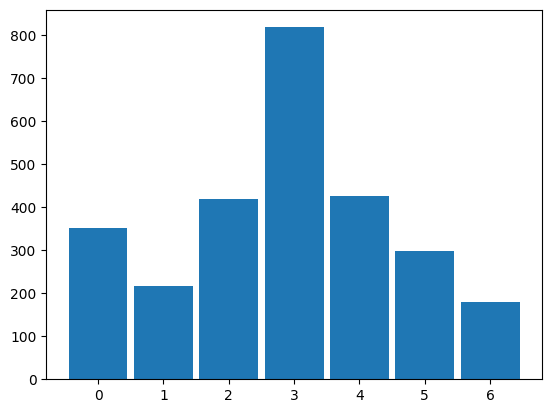

In [5]:
#Distribution of node labels?
fig, ax = plt.subplots()
labels = dataset.data.y
ax.hist(labels, bins=np.arange(8)-0.5, rwidth=0.9)
print()

Recall that the nodes represent a research paper. The corresponding label is the research subfield. The dictionary below gives the subfield associated to each label.



In [6]:
label_map = {0: 'Theory',
             1: 'Reinforcement Learning',
             2: 'Genetic Algorithms',
             3: 'Neural Networks',
             4: 'Probabilistic Methods',
             5: 'Case Based',
             6: 'Rule Learning'}

The graph is too large to visualise effectively so visualise instead a subset of the data.

In [7]:
from matplotlib.colors import ListedColormap
K = len(label_map)
cmap = ListedColormap(plt.get_cmap("tab10").colors[:K])

def plot_subset(data, ax, pos, seed=0):
    graph_nx = to_networkx(data, node_attrs=['y'], to_undirected=True)
    subgraph_nx = graph_nx.subgraph(pos.keys())

    nodelist = list(subgraph_nx.nodes())
    node_size = [10*(subgraph_nx.degree(node)+1) for node in nodelist]
    color = [graph_nx.nodes[node]['y'] for node in nodelist]

    nx.draw_networkx_nodes(
        subgraph_nx, pos=pos, nodelist=nodelist,
        node_size=node_size, node_color=color,
        cmap=cmap, ax=ax
    )
    nx.draw_networkx_edges(subgraph_nx, pos=pos, alpha=0.2, ax=ax)
    ax.axis("off")

def subgraph_layout(data, seed=0):
    """Defines coordinates for a subsgraph of data."""

    # set seed
    np.random.seed(seed)

    # change to networkx and select largest connected component
    data = deepcopy(data)
    graph_nx = to_networkx(data, node_attrs=['y'], to_undirected=True)
    subgraph_nx = graph_nx.subgraph(max(nx.connected_components(graph_nx), key=len))

    # select a subgraph
    random_node = np.random.choice(subgraph_nx.nodes())
    subgraph_nx = nx.ego_graph(subgraph_nx, random_node, radius=3)

    # calculate pos
    pos = nx.spring_layout(subgraph_nx)
    return pos


/tmp/ipython-input-3355720703.py:2: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  pos = subgraph_layout(dataset.data, seed=0)
/tmp/ipython-input-3355720703.py:3: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  plot_subset(dataset.data, ax, pos)


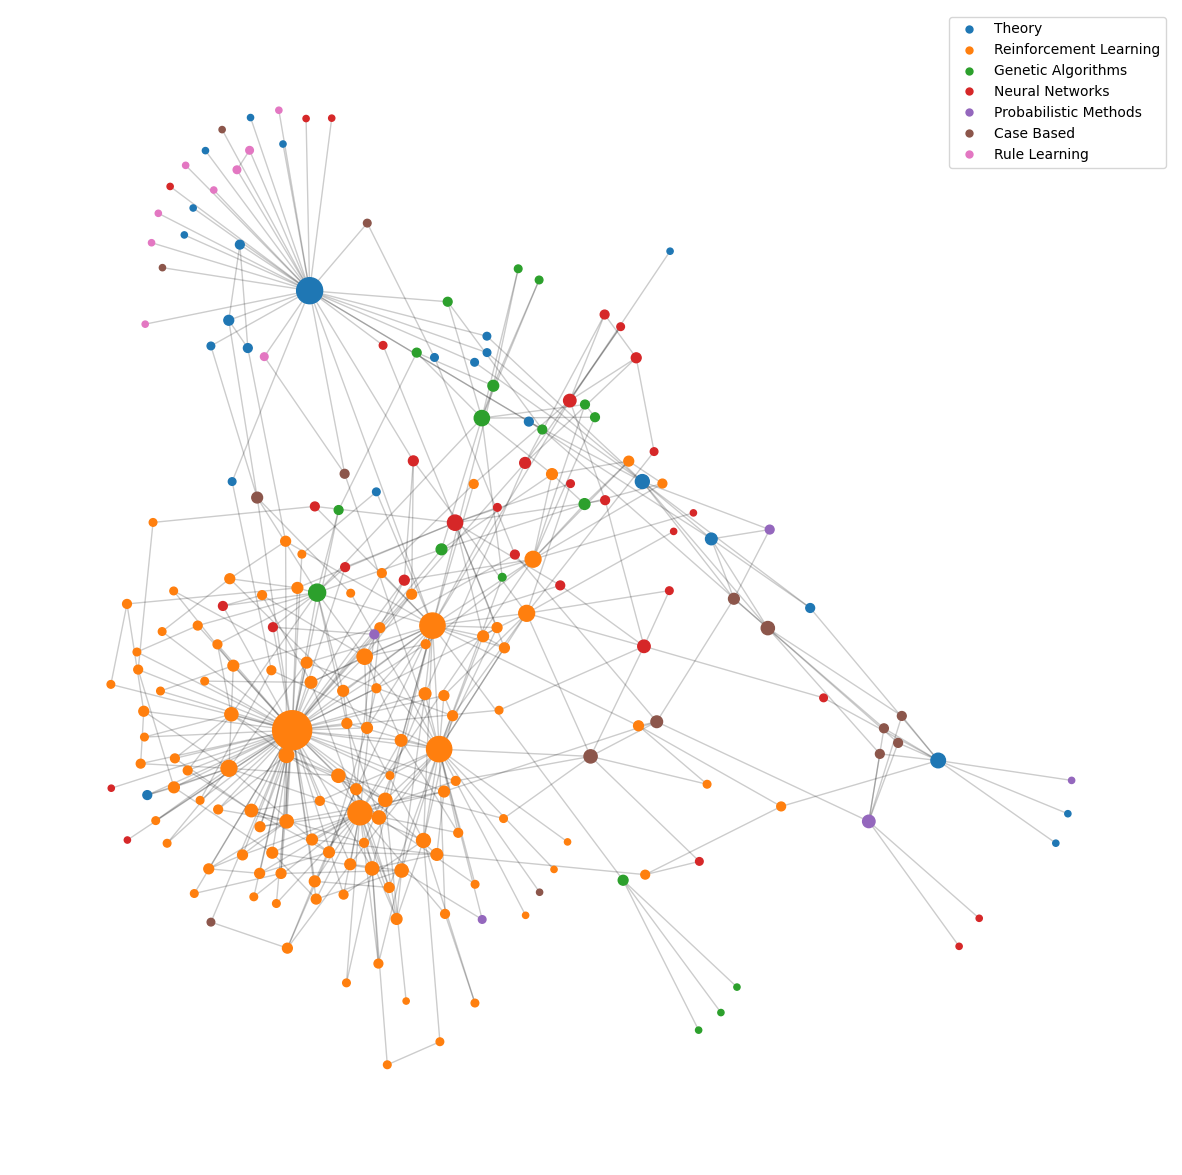

In [8]:
fig, ax = plt.subplots(figsize=(15, 15))
pos = subgraph_layout(dataset.data, seed=0)
plot_subset(dataset.data, ax, pos)

handles = [plt.Line2D([0],[0], marker='o', linestyle='None',
                      markerfacecolor=cmap(i), markeredgecolor='none')
           for i in range(K)]
ax.legend(handles, [label_map[i] for i in range(K)])

## Part 1: Building a GNN
In this part, you will build a GNN using PyTorch, aiming to emulate the PyTorch Geometric modules. You will construct your neural network using PyTorch nn modules, and build training and testing helper functions to train and evaluate your model.

### Task 1.1
Understand the base structure of a PyTorch neural network model, namely `torch.nn.Module`, and build your GNN as a class with its own instantiation of `__init__` and `forward`. You will define GNN components within `__init__`, and construct the GNN data flow in `forward`. We recommend that you construct your model such that the number of layers is parametrized. That is, you can increase or decrease the number of layers simply by changing the range of an inner loop that creates the needed layers.

Furthermore, as a node classification GNN is composed by a sequence of Graph Convolution Layers and by a Multi Layer Perceptron head used to classify each node, we suggest to define a separate module for each of these components, and then aggregate them together in the final model.

Please complete the following classes, adding the respective `__init__` and `forward` methods.  
Please construct your model such that the number of layers is parametrized. That is, you can increase or decrease the number of layers simply by changing the range of an inner loop that creates the needed layers. In general, try to hard-code the least amount of behaviour inside your network. Prefer, instead, the use of parameters passed during initialization, as it will come in handy later on (e.g., you can chosse to hard code the activation functions used for each model but also leave them as a model parameter).

A `GNNLayer` computes the operations seen in the lectures, that is:

$ h_i^{(t+1)} = \sigma(W^{(t)}_{self} h_i^{(t)} + W^{(t)}_{neigh} \sum_{j \in neigh(i)} h_j^{(t)})$.

Remember that PyTorch is realy efficient in parallelizing computations by vectorizing them. In other words, you don't need to (you must not!) loop over all the neighbours of each node to compute the summation in the above equation. Use instead matrix operations.

In [9]:
class GNNLayer(nn.Module):

    def __init__(self, input_dim, output_dim):
      super().__init__()
      self.W_self = nn.Linear(input_dim, output_dim)
      self.W_neigh = nn.Linear(input_dim, output_dim)

    def forward(self, node_feats, adj_matrix):
        # We don't apply the activation function here but in GNNModule (contrary to the above text?)
        return self.W_self(node_feats) + self.W_neigh(adj_matrix @ node_feats)

The `GNNModule` is a collection of GNNLayers. In PyTorch you can create a list of layers by using `nn.ModuleList(layer_1, layer_2, ...)` or, equivalentely `nn.ModuleList(*layer_list)`. Remember activation functions!

In [10]:
class GNNModule(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, act_fn=nn.ReLU):
      super().__init__()
      self.layer_list = []

      self.layer_list.append(GNNLayer(input_dim, hidden_dim))
      for i in range(num_layers-2):
        self.layer_list.append(GNNLayer(hidden_dim, hidden_dim))
      self.layer_list.append(GNNLayer(hidden_dim, output_dim))

      self.layers = nn.ModuleList(self.layer_list)
      self.act_fn = act_fn

    def forward(self, x, adj_matrix):
      for layer in self.layer_list:
        x = self.act_fn(layer.forward(x, adj_matrix))
      return x


The `MLPModule` is a classification head that you apply to each node in the input graph after applying the gnn layers. It is a collection of `nn.Linear` layers.

In [11]:
class MLPModule(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, act_fn=nn.ReLU):
      super().__init__()
      self.layer_list = []

      self.layer_list.append(nn.Linear(input_dim, hidden_dim))
      for i in range(num_layers-2):
        self.layer_list.append(nn.Linear(hidden_dim, hidden_dim))
      self.layer_list.append(nn.Linear(hidden_dim, output_dim))

      self.layers = nn.ModuleList(self.layer_list)
      self.act_fn = act_fn

    def forward(self, x):
      for layer in self.layer_list:
        x = self.act_fn(layer.forward(x))
      return x

Let's aggregate everything in a single class:

In [98]:
class CoraNodeClassification(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim, gnn_num_layers, mlp_num_layers, gnn_act_fn, mlp_act_fn):
        super().__init__()
        self.gnn_module = GNNModule(input_dim, hidden_dim, hidden_dim, gnn_num_layers, gnn_act_fn)
        self.mlp_module = MLPModule(hidden_dim, hidden_dim, output_dim, mlp_num_layers, mlp_act_fn)


    def forward(self, x, adj_matrix):
        x = self.gnn_module.forward(x, adj_matrix, self.forward_mlp)
        x = self.mlp_module.forward(x)
        return x


    # Used to reset the weights of the network when training multiple times with
    # different hyperparameters
    def reset_parameters(self):
        def _reset_module_parameters(module):
            for layer in module.children():
                if hasattr(layer, 'reset_parameters'):
                    layer.reset_parameters()
                elif hasattr(layer, 'children'):
                    for child_layer in layer.children():
                        _reset_module_parameters(child_layer)

        _reset_module_parameters(self)

### Task 1.2
Create dedicated functions for training and testing. For training, your functions should return a vector containing the train loss and accuracy after each epoch (since Cora contains a single graph one epoch corresponds to one training iteration). You can also print out those values while the training it's running. However, given the large number of epochs, we advise you print every 8 steps or so. Your test function should return the final accuracy on the test set. If everything works correctly you should get around ~75% accuracy.

Cora uses a masking approach to divide between the train and test set. Therefore, to compute the loss/accuracy, mask out the part of your output based on the current settings, e.g., `loss = model.loss_fn(y[data.train_mask], data.y[data.train_mask])`

In [68]:
# The Cora dataset contains a single graph of 2708 nodes (i.e., papers).
# We will use some of the nodes as training set and some as test set.
data = dataset[0].to(device)

# According to the GNN equations, we need the adjacency matrix to compute each
# layer convolution. The following line convert the sparse data
# (i.e., list of edges) stored in the dataset in a single dense matrix.
adj_matrix = U.to_dense_adj(data.edge_index).squeeze(0)

# Define the hyperparameters we are gonna use:
params = {
    "hidden_features": 128,
    "num_gcn_layers": 2,
    "num_mlp_layers": 2,
    "learning_rate": 1e-4,
    "weight_decay": 0,
    "num_epochs": 256,
}

# Remember to move the model to the correct device using `.to(device)`
# The arguments to be passed to the class CoraNodeClassification __init__ functions
# depends on how you defined the method. This is an example.
model = CoraNodeClassification(num_features,
                               params["hidden_features"],
                               num_classes,
                               params["num_gcn_layers"],
                               params["num_mlp_layers"],
                               gnn_act_fn=F.relu, #ID is the identity function, replace it with the activation function you'd like to use
                               mlp_act_fn=F.relu
  ).to(device)

In [69]:
def test(model, data, adj_matrix, params):
    model.eval()
    logits = F.softmax(model.forward(data.x, adj_matrix), dim=1)
    output = logits.argmax(dim=1)
    test_accuracy = (output[data.test_mask] == data.y[data.test_mask]).sum().float() / data.test_mask.sum().float()
    return test_accuracy


# By testing a random initialized module you should get around ~15% accuracy
test(model, data, adj_matrix, params)

tensor(0.1880, device='cuda:0')

In [70]:
def train(model, data, adj_matrix, params):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])
    loss_fn = nn.CrossEntropyLoss()
    losses, accuracies = [], []

    for epoch in range(params["num_epochs"]):
        optimizer.zero_grad()
        logits = model.forward(data.x, adj_matrix)
        output = F.softmax(logits, dim=1).argmax(dim=1)
        accuracy = (output[data.train_mask] == data.y[data.train_mask]).sum().float() / data.train_mask.sum().float()
        accuracies.append(accuracy)

        loss = loss_fn(logits[data.train_mask], data.y[data.train_mask])
        losses.append(loss.item())
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 8 == 0:
            print(f"Epoch {epoch+1}/{params["num_epochs"]} Loss: {loss.item():.2f} Train Accuracy: {accuracy*100:.2f}%")
    return losses, accuracies


train_losses, train_accuracies = train(model, data, adj_matrix, params)
# Now you shold get around ~75-77%!
test_accuracy = test(model, data, adj_matrix, params)
print("Final test accuracy:", test_accuracy)

Epoch 8/256 Loss: 1.87 Train Accuracy: 41.43%
Epoch 16/256 Loss: 1.76 Train Accuracy: 52.14%
Epoch 24/256 Loss: 1.62 Train Accuracy: 66.43%
Epoch 32/256 Loss: 1.48 Train Accuracy: 73.57%
Epoch 40/256 Loss: 1.34 Train Accuracy: 86.43%
Epoch 48/256 Loss: 1.18 Train Accuracy: 90.71%
Epoch 56/256 Loss: 1.02 Train Accuracy: 94.29%
Epoch 64/256 Loss: 0.86 Train Accuracy: 96.43%
Epoch 72/256 Loss: 0.71 Train Accuracy: 98.57%
Epoch 80/256 Loss: 0.58 Train Accuracy: 99.29%
Epoch 88/256 Loss: 0.48 Train Accuracy: 100.00%
Epoch 96/256 Loss: 0.39 Train Accuracy: 100.00%
Epoch 104/256 Loss: 0.32 Train Accuracy: 100.00%
Epoch 112/256 Loss: 0.26 Train Accuracy: 100.00%
Epoch 120/256 Loss: 0.21 Train Accuracy: 100.00%
Epoch 128/256 Loss: 0.18 Train Accuracy: 100.00%
Epoch 136/256 Loss: 0.15 Train Accuracy: 100.00%
Epoch 144/256 Loss: 0.12 Train Accuracy: 100.00%
Epoch 152/256 Loss: 0.10 Train Accuracy: 100.00%
Epoch 160/256 Loss: 0.09 Train Accuracy: 100.00%
Epoch 168/256 Loss: 0.07 Train Accuracy: 10

#### Task 1.2.1
Can you modify the training function to return the test accuracy at every step as well?
By plotting the train accuracy and test accuracy over time, what can you observe?


In [73]:
def train(model, data, adj_matrix, params):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])
    loss_fn = nn.CrossEntropyLoss()
    losses, accuracies = [], []
    test_accuracies = [] ### ADDED

    for epoch in range(params["num_epochs"]):
        optimizer.zero_grad()
        logits = model.forward(data.x, adj_matrix)
        output = F.softmax(logits, dim=1).argmax(dim=1)
        accuracy = (output[data.train_mask] == data.y[data.train_mask]).sum().float() / data.train_mask.sum().float()
        accuracies.append(accuracy.item())

        loss = loss_fn(logits[data.train_mask], data.y[data.train_mask])
        losses.append(loss.item())
        loss.backward()
        optimizer.step()

        ### ADDED
        model.eval()
        t_accuracy = (output[data.test_mask] == data.y[data.test_mask]).sum().float() / data.test_mask.sum().float()
        test_accuracies.append(t_accuracy.item())
        model.train()

        if (epoch + 1) % 8 == 0:
            ### EDITED
            print(f"Epoch {epoch+1}/{params["num_epochs"]} Loss: {loss.item():.2f} Train Accuracy: {accuracy*100:.2f}% Test Accuracy: {t_accuracy*100:.2f}%")
    return losses, accuracies, test_accuracies

Epoch 8/256 Loss: 1.81 Train Accuracy: 43.57% Test Accuracy: 27.70%
Epoch 16/256 Loss: 1.69 Train Accuracy: 60.00% Test Accuracy: 41.90%
Epoch 24/256 Loss: 1.58 Train Accuracy: 73.57% Test Accuracy: 52.50%
Epoch 32/256 Loss: 1.45 Train Accuracy: 84.29% Test Accuracy: 62.90%
Epoch 40/256 Loss: 1.32 Train Accuracy: 89.29% Test Accuracy: 69.30%
Epoch 48/256 Loss: 1.16 Train Accuracy: 92.86% Test Accuracy: 71.90%
Epoch 56/256 Loss: 1.00 Train Accuracy: 95.71% Test Accuracy: 73.80%
Epoch 64/256 Loss: 0.83 Train Accuracy: 97.14% Test Accuracy: 75.00%
Epoch 72/256 Loss: 0.68 Train Accuracy: 97.86% Test Accuracy: 75.30%
Epoch 80/256 Loss: 0.55 Train Accuracy: 97.86% Test Accuracy: 74.80%
Epoch 88/256 Loss: 0.45 Train Accuracy: 99.29% Test Accuracy: 75.30%
Epoch 96/256 Loss: 0.37 Train Accuracy: 100.00% Test Accuracy: 75.40%
Epoch 104/256 Loss: 0.30 Train Accuracy: 100.00% Test Accuracy: 75.90%
Epoch 112/256 Loss: 0.24 Train Accuracy: 100.00% Test Accuracy: 76.10%
Epoch 120/256 Loss: 0.20 Train

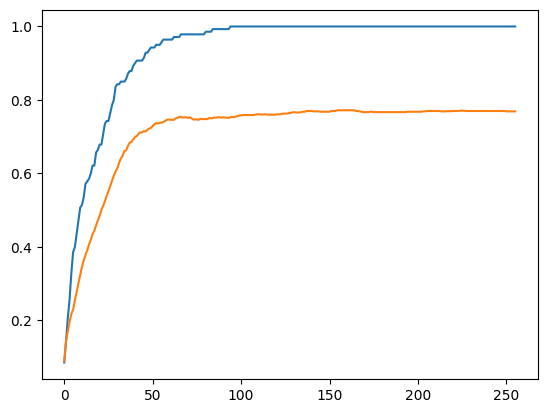

Final test accuracy: 0.7689999938011169


In [77]:
model = CoraNodeClassification(num_features,
                               params["hidden_features"],
                               num_classes,
                               params["num_gcn_layers"],
                               params["num_mlp_layers"],
                               gnn_act_fn=F.relu, #ID is the identity function, replace it with the activation function you'd like to use
                               mlp_act_fn=F.relu
  ).to(device)

train_losses, train_accuracies, test_accuracies = train(model, data, adj_matrix, params)

import matplotlib.pyplot as plt

plt.plot(train_accuracies)
plt.plot(test_accuracies)
plt.show()

print("Final test accuracy:", test_accuracies[-1])

## Part 2: Ablation Studies (Optional)

### 2.1: Importance of GNN and MLP modules
Add a parameter to the `CoraNodeClassification` class that allows you to select which modules to enable: only GNN, only MLP, or both. For example, your `forward` should look similarly to the following:

```python
def forward(self, x, adj_matrix):
    if self.gnn is not None:
      x = self.gnn(x, adj_matrix)
    
    if self.mlp is not None:
      x = self.mlp(x)

    return x
```

What is the impact of the two modules on the final result? Play a little around `hidden_features` and `num_layers` and briefly describe what you observe.

In [114]:
class CoraNodeClassification(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim, gnn_num_layers, mlp_num_layers, gnn_act_fn, mlp_act_fn,
                 forward_gnn=True, forward_mlp=True): # Extra arguments for optional part
        super().__init__()
        self.gnn_module = GNNModule(input_dim, hidden_dim, hidden_dim, gnn_num_layers, gnn_act_fn)
        self.mlp_module = MLPModule(hidden_dim, hidden_dim, output_dim, mlp_num_layers, mlp_act_fn)

        # Extra arguments for optional part
        self.forward_gnn = forward_gnn
        self.forward_mlp = forward_mlp
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.extra_layer = nn.Linear(self.input_dim, self.hidden_dim).to(device)


    def forward(self, x, adj_matrix):
        if self.forward_gnn:
            x = self.gnn_module.forward(x, adj_matrix)
        else:
            x = self.extra_layer(x)

        if self.forward_mlp:
            x = self.mlp_module.forward(x)
        return x


    # Used to reset the weights of the network when training multiple times with
    # different hyperparameters
    def reset_parameters(self):
        def _reset_module_parameters(module):
            for layer in module.children():
                if hasattr(layer, 'reset_parameters'):
                    layer.reset_parameters()
                elif hasattr(layer, 'children'):
                    for child_layer in layer.children():
                        _reset_module_parameters(child_layer)

        _reset_module_parameters(self)

In [117]:
model_gnn_only = CoraNodeClassification(num_features, params["hidden_features"], num_classes, params["num_gcn_layers"],
                               params["num_mlp_layers"], gnn_act_fn=F.relu, mlp_act_fn=F.relu, forward_mlp=False).to(device)
train_losses, train_accuracies, test_accuracies = train(model_gnn_only, data, adj_matrix, params)

Epoch 8/256 Loss: 4.40 Train Accuracy: 21.43% Test Accuracy: 15.10%
Epoch 16/256 Loss: 3.74 Train Accuracy: 52.86% Test Accuracy: 34.60%
Epoch 24/256 Loss: 3.16 Train Accuracy: 67.86% Test Accuracy: 50.80%
Epoch 32/256 Loss: 2.68 Train Accuracy: 77.86% Test Accuracy: 54.70%
Epoch 40/256 Loss: 2.28 Train Accuracy: 86.43% Test Accuracy: 57.90%
Epoch 48/256 Loss: 1.95 Train Accuracy: 91.43% Test Accuracy: 62.90%
Epoch 56/256 Loss: 1.69 Train Accuracy: 95.00% Test Accuracy: 65.00%
Epoch 64/256 Loss: 1.49 Train Accuracy: 95.71% Test Accuracy: 67.00%
Epoch 72/256 Loss: 1.31 Train Accuracy: 97.14% Test Accuracy: 68.00%
Epoch 80/256 Loss: 1.16 Train Accuracy: 97.86% Test Accuracy: 68.90%
Epoch 88/256 Loss: 1.04 Train Accuracy: 98.57% Test Accuracy: 69.50%
Epoch 96/256 Loss: 0.93 Train Accuracy: 99.29% Test Accuracy: 69.70%
Epoch 104/256 Loss: 0.84 Train Accuracy: 99.29% Test Accuracy: 69.70%
Epoch 112/256 Loss: 0.76 Train Accuracy: 99.29% Test Accuracy: 70.00%
Epoch 120/256 Loss: 0.69 Train Ac

In [125]:
model_mlp_only = CoraNodeClassification(num_features, params["hidden_features"], num_classes, params["num_gcn_layers"],
                               params["num_mlp_layers"], gnn_act_fn=F.relu, mlp_act_fn=F.relu, forward_gnn=False).to(device)
train_losses, train_accuracies, test_accuracies = train(model_mlp_only, data, adj_matrix, params)

Epoch 8/256 Loss: 1.93 Train Accuracy: 37.86% Test Accuracy: 16.50%
Epoch 16/256 Loss: 1.92 Train Accuracy: 52.14% Test Accuracy: 20.50%
Epoch 24/256 Loss: 1.91 Train Accuracy: 57.86% Test Accuracy: 23.00%
Epoch 32/256 Loss: 1.89 Train Accuracy: 61.43% Test Accuracy: 25.40%
Epoch 40/256 Loss: 1.87 Train Accuracy: 64.29% Test Accuracy: 28.00%
Epoch 48/256 Loss: 1.85 Train Accuracy: 67.14% Test Accuracy: 29.00%
Epoch 56/256 Loss: 1.82 Train Accuracy: 68.57% Test Accuracy: 30.50%
Epoch 64/256 Loss: 1.79 Train Accuracy: 69.29% Test Accuracy: 30.80%
Epoch 72/256 Loss: 1.75 Train Accuracy: 70.71% Test Accuracy: 31.40%
Epoch 80/256 Loss: 1.71 Train Accuracy: 70.71% Test Accuracy: 31.60%
Epoch 88/256 Loss: 1.66 Train Accuracy: 71.43% Test Accuracy: 31.90%
Epoch 96/256 Loss: 1.60 Train Accuracy: 71.43% Test Accuracy: 32.50%
Epoch 104/256 Loss: 1.54 Train Accuracy: 71.43% Test Accuracy: 32.90%
Epoch 112/256 Loss: 1.47 Train Accuracy: 71.43% Test Accuracy: 32.90%
Epoch 120/256 Loss: 1.40 Train Ac

In [93]:
model_2xdepth = CoraNodeClassification(num_features, params["hidden_features"], num_classes, params["num_gcn_layers"]*2,
                               params["num_mlp_layers"]*2, gnn_act_fn=F.relu, mlp_act_fn=F.relu).to(device)
train_losses, train_accuracies, test_accuracies = train(model_2xdepth, data, adj_matrix, params)

Epoch 8/256 Loss: 1.70 Train Accuracy: 32.14% Test Accuracy: 28.10%
Epoch 16/256 Loss: 1.60 Train Accuracy: 40.00% Test Accuracy: 39.80%
Epoch 24/256 Loss: 1.53 Train Accuracy: 43.57% Test Accuracy: 44.30%
Epoch 32/256 Loss: 1.46 Train Accuracy: 49.29% Test Accuracy: 49.40%
Epoch 40/256 Loss: 1.38 Train Accuracy: 52.14% Test Accuracy: 50.70%
Epoch 48/256 Loss: 1.29 Train Accuracy: 62.14% Test Accuracy: 55.00%
Epoch 56/256 Loss: 1.15 Train Accuracy: 66.43% Test Accuracy: 60.50%
Epoch 64/256 Loss: 1.02 Train Accuracy: 70.00% Test Accuracy: 61.30%
Epoch 72/256 Loss: 0.91 Train Accuracy: 72.86% Test Accuracy: 63.10%
Epoch 80/256 Loss: 0.82 Train Accuracy: 75.71% Test Accuracy: 64.30%
Epoch 88/256 Loss: 0.75 Train Accuracy: 77.14% Test Accuracy: 64.30%
Epoch 96/256 Loss: 0.69 Train Accuracy: 77.86% Test Accuracy: 63.50%
Epoch 104/256 Loss: 0.63 Train Accuracy: 77.86% Test Accuracy: 63.60%
Epoch 112/256 Loss: 0.59 Train Accuracy: 77.86% Test Accuracy: 64.70%
Epoch 120/256 Loss: 0.55 Train Ac

In [92]:
model_2xfeatures = CoraNodeClassification(num_features, params["hidden_features"]*2, num_classes, params["num_gcn_layers"]*2,
                               params["num_mlp_layers"], gnn_act_fn=F.relu, mlp_act_fn=F.relu).to(device)
train_losses, train_accuracies, test_accuracies = train(model_2xfeatures, data, adj_matrix, params)

Epoch 8/256 Loss: 1.81 Train Accuracy: 35.71% Test Accuracy: 28.80%
Epoch 16/256 Loss: 1.75 Train Accuracy: 32.14% Test Accuracy: 27.40%
Epoch 24/256 Loss: 1.68 Train Accuracy: 37.14% Test Accuracy: 29.10%
Epoch 32/256 Loss: 1.61 Train Accuracy: 41.43% Test Accuracy: 30.30%
Epoch 40/256 Loss: 1.52 Train Accuracy: 45.71% Test Accuracy: 31.50%
Epoch 48/256 Loss: 1.44 Train Accuracy: 50.71% Test Accuracy: 31.50%
Epoch 56/256 Loss: 1.36 Train Accuracy: 54.29% Test Accuracy: 36.50%
Epoch 64/256 Loss: 1.23 Train Accuracy: 58.57% Test Accuracy: 47.10%
Epoch 72/256 Loss: 1.14 Train Accuracy: 62.14% Test Accuracy: 50.30%
Epoch 80/256 Loss: 1.13 Train Accuracy: 64.29% Test Accuracy: 48.20%
Epoch 88/256 Loss: 1.20 Train Accuracy: 63.57% Test Accuracy: 50.00%
Epoch 96/256 Loss: 1.01 Train Accuracy: 66.43% Test Accuracy: 50.30%
Epoch 104/256 Loss: 0.99 Train Accuracy: 65.00% Test Accuracy: 51.70%
Epoch 112/256 Loss: 0.97 Train Accuracy: 66.43% Test Accuracy: 50.60%
Epoch 120/256 Loss: 0.95 Train Ac

### 2.2: Importance of non-linearities
Try to replace all your activation functions with identities (or simply remove them). Do the results change? What does this tell you about this specific problem?

In [133]:
def identity(x):
    return x

model_id_af = CoraNodeClassification(num_features, params["hidden_features"], num_classes, params["num_gcn_layers"],
                               params["num_mlp_layers"], gnn_act_fn=identity, mlp_act_fn=identity).to(device)
train_losses, train_accuracies, test_accuracies = train(model_id_af, data, adj_matrix, params)

Epoch 8/256 Loss: 1.59 Train Accuracy: 47.14% Test Accuracy: 35.30%
Epoch 16/256 Loss: 1.34 Train Accuracy: 73.57% Test Accuracy: 55.60%
Epoch 24/256 Loss: 1.14 Train Accuracy: 82.86% Test Accuracy: 61.80%
Epoch 32/256 Loss: 0.96 Train Accuracy: 90.00% Test Accuracy: 66.90%
Epoch 40/256 Loss: 0.80 Train Accuracy: 95.00% Test Accuracy: 69.50%
Epoch 48/256 Loss: 0.66 Train Accuracy: 95.71% Test Accuracy: 71.00%
Epoch 56/256 Loss: 0.54 Train Accuracy: 97.86% Test Accuracy: 72.10%
Epoch 64/256 Loss: 0.45 Train Accuracy: 98.57% Test Accuracy: 73.00%
Epoch 72/256 Loss: 0.36 Train Accuracy: 99.29% Test Accuracy: 73.10%
Epoch 80/256 Loss: 0.30 Train Accuracy: 99.29% Test Accuracy: 73.80%
Epoch 88/256 Loss: 0.24 Train Accuracy: 100.00% Test Accuracy: 74.10%
Epoch 96/256 Loss: 0.20 Train Accuracy: 100.00% Test Accuracy: 74.30%
Epoch 104/256 Loss: 0.16 Train Accuracy: 100.00% Test Accuracy: 74.70%
Epoch 112/256 Loss: 0.13 Train Accuracy: 100.00% Test Accuracy: 74.80%
Epoch 120/256 Loss: 0.11 Trai

This tells me that this task is simple enough to be solved by one GNN Layer and one MLP layer, since these layers without non-linearities can be combined in one. The classes appear almost linearly separable.